In [1]:
using Pkg
Pkg.activate(normpath(joinpath(@__DIR__, "..")))

  Activating project at `~/DART`


In [3]:
using JLD2

include(normpath(joinpath(@__DIR__, "..", "utils", "utils.jl")));

In [6]:
data_dir = "../synthetic_data/ideal_data_res"

function load_files(prefix; dir=data_dir)
    files = [
        "$(prefix)_dlb33_compare_seed_58.jld2",
        "$(prefix)_dlnb133_compare_seed_11.jld2",
        "$(prefix)_dlnb033_compare_seed_49.jld2",
    ]
    mets = map(files) do f
        @load joinpath(dir, f) rn_met_dl
        rn_met_dl
    end
    return vcat(mets...)
end

m2_met   = load_files("mm2")
ref_met  = load_files("mref")
gen2_met = load_files("mgen2");

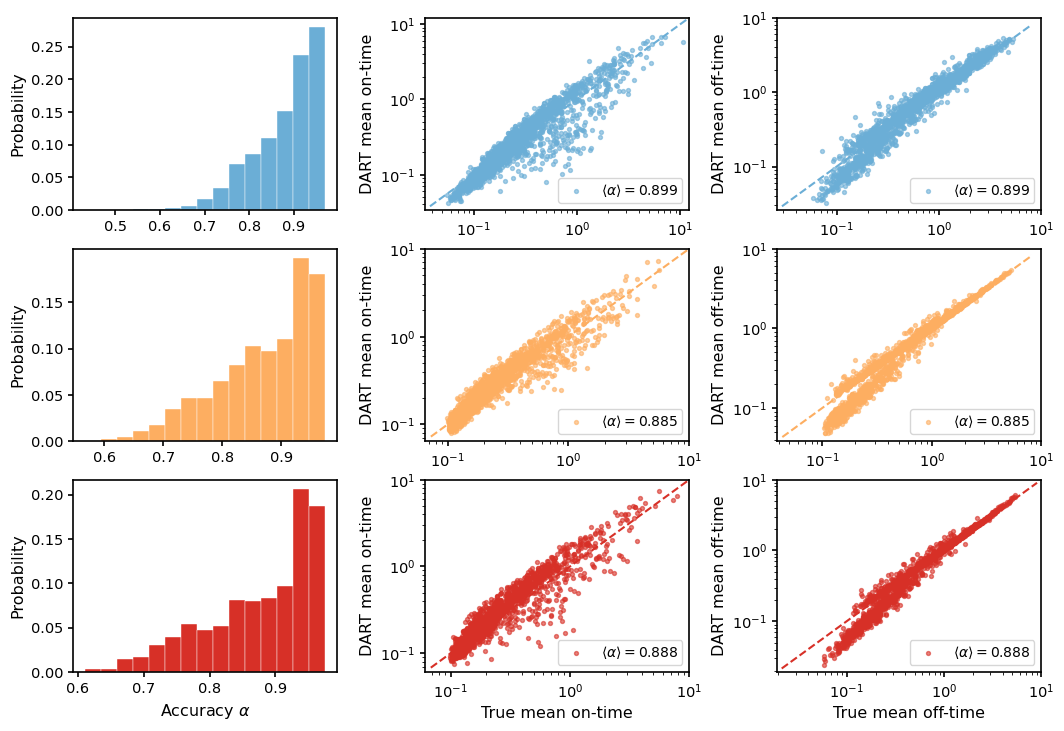

In [13]:
function scatter_plot(ax, rn_met, x_data, y_data, label_pos;
                      axis_log=true,
                      pt_color="#67a9cf",
                      line_color="#2c7bb6")

    rn_acc = [m.acc for m in rn_met]
    macc = round(mean(rn_acc), digits=3)

    sc = ax.scatter(x_data, y_data, s=8,c=pt_color, alpha=0.6, label=L"\langle \alpha \rangle=" * string(macc))
    sc.set_rasterized(true)

    ax.legend(borderpad=0.3, fontsize=10, loc="lower right")

    x_min, x_max = minimum(vcat(x_data,y_data)), maximum(vcat(x_data,y_data))
    ax.plot(x_min*0.9:0.1:x_max*1.5, x_min*0.9:0.1:x_max*1.5,
            c=line_color, linestyle="--", linewidth=1.5)

    ax.set_xlim(x_min * 0.8, x_max * 1.15)
    ax.set_ylim(x_min * 0.8, x_max * 1.15)

    if axis_log
        ax.set_xscale("log")
        ax.set_yscale("log")
    end
end

function plot_rn3(m2_met, ref_met, gen2_met)
    cm = 1/2.54
    fig, ax = plt.subplots(3, 3, figsize=(12.5, 8.5)) #, constrained_layout=true

    fig.subplots_adjust(wspace=0.33, hspace=0.2)

    mets = [m2_met, ref_met, gen2_met]
    fs1 = 11.5; fs2 = 10.5

    # 3 colors picked from your RdBu (avoid near-white)
    row_pt   = ["#6baed6", "#fdae61", "#d73027"]  # points (red / light-orange / blue)
    row_line = ["#6baed6", "#fdae61", "#d73027"]  # diagonal (slightly darker for mid row)
    row_hist = ["#6baed6", "#fdae61", "#d73027"]  # histogram fill

    for i in 1:3
        rn_met = mets[i]
        accs = [m.acc for m in rn_met]

        # hist (left column)
        counts, bins = np.histogram(accs, bins=15)
        ncounts = counts ./ sum(counts)
        ax[i,1].set_axisbelow(true)
        ax[i,1].bar(bins[1:end-1], ncounts, width=diff(bins),
                    color=row_hist[i], alpha=1.0,
                    edgecolor="white", lw=0.3)

        y_ticks = 0:0.05:maximum(ncounts)
        ax[i,1].set_yticks(y_ticks)
        ax[i,1].set_ylabel("Probability", fontsize=fs1)

        # scatter (middle/right)
        scatter_plot(ax[i,2], rn_met,
            [m.truet_mean[1] for m in rn_met],
            [m.binart_mean[1] for m in rn_met], (0.6, 0.1);
            pt_color=row_pt[i], line_color=row_line[i])

        scatter_plot(ax[i,3], rn_met,
            [m.truet_mean[2] for m in rn_met],
            [m.binart_mean[2] for m in rn_met], (0.6, 0.1);
            pt_color=row_pt[i], line_color=row_line[i])

        ax[i,2].set_ylabel("DART mean on-time", fontsize=fs1)
        ax[i,3].set_ylabel("DART mean off-time", fontsize=fs1)

        # log轴修正（你原样保留；注意这里应是 ax[i,2], ax[i,3]）
        for a in (ax[i,2], ax[i,3])
            if String(a[:get_yscale]()) == "log"
                y0, y1 = a[:get_ylim]()
                a[:set_ylim]([y0, max(y1, 10.0^1)])
                a[:get_yaxis]()[:set_major_formatter](
                    plt[:FuncFormatter]((v,p)->"\$10^{$(Int(round(log10(v))))}\$")
                )
            end
            if String(a[:get_xscale]()) == "log"
                x0, x1 = a[:get_xlim]()
                a[:set_xlim]([x0, max(x1, 10.0^1)])
            end
        end
    end

    wd = 1.2
    for i in 1:3, j in 1:3
        ax[i,j].tick_params(axis="both", labelsize=10.5, width=wd)
        for spine in ax[i,j].spines.values()
            spine.set_linewidth(wd)
        end
    end

    ax[3,1].set_xlabel(L"Accuracy $\alpha$", fontsize=fs1)
    ax[3,2].set_xlabel("True mean on-time", fontsize=fs1)
    ax[3,3].set_xlabel("True mean off-time", fontsize=fs1)

    return fig
end;

fig = plot_rn3(gen2_met, ref_met, m2_met);
#fig.savefig("figs/unseen_models2.pdf", bbox_inches="tight", dpi=800);

#### R^2

In [110]:
#### correlation calculations
m2_trues = [m.truet_mean for m in m2_met]
m2_vals = [m.binart_mean for m in m2_met];

ref_trues = [m.truet_mean for m in ref_met]
ref_vals = [m.binart_mean for m in ref_met];

gen2_trues = [m.truet_mean for m in gen2_met]
gen2_vals = [m.binart_mean for m in gen2_met];

In [112]:
fit_line(map(x->x[1],m2_trues),map(x->x[1],m2_vals))[3],fit_line(map(x->x[2],m2_trues),map(x->x[2],m2_vals))[3]

(0.856589563898824, 0.9912360621511066)

In [113]:
fit_line(map(x->x[1],ref_trues),map(x->x[1],ref_vals))[3],fit_line(map(x->x[2],ref_trues),map(x->x[2],ref_vals))[3]

(0.8436206509521451, 0.9912672639206835)

In [114]:
fit_line(map(x->x[1],gen2_trues),map(x->x[1],gen2_vals))[3],fit_line(map(x->x[2],gen2_trues),map(x->x[2],gen2_vals))[3]

(0.8229044422579123, 0.9599125222317111)